# Modelo LSTM
### TCC —  PREDIÇÃO DE CONSUMO DE ENERGIA ELÉTRICA EM AMBIENTE DE SMART CAMPUS UTILIZANDO REDES NEURAIS LSTM
---

Este notebook dá continuidade ao pré-processamento já realizado e inicia nossa implementação do modelo de rede neural **LSTM** para prever o consumo de energia das **próximas 24 horas**.

### O que será feito aqui:

1. Carregar os dados já limpos e com features criadas (saída do notebook anterior)
2. Entender o conceito de **janela deslizante** (como o LSTM "enxerga" o tempo)
3. Dividir os dados corretamente em **treino e teste**
4. **Normalizar** os dados (etapa essencial para redes neurais)
5. Criar as **sequências de entrada** para o LSTM
6. Montar e treinar a **arquitetura LSTM**
7. Avaliar o modelo com as métricas **RMSE, MAE, MAPE e R²**
8. Visualizar as **previsões vs. valores reais**

---

 **Pré-requisito:** executar primeiro o notebook de pré-processamento para gerar o arquivo `db_building_A_features.csv` ou `db_building_B_features.csv`


---
## 1 — Instalação e Importação das Bibliotecas


- **pandas / numpy**: manipulação de dados e operações numéricas
- **matplotlib / seaborn**: gráficos
- **scikit-learn**: normalização e métricas de avaliação
- **tensorflow / keras**: construção e treinamento da rede neural LSTM

docs oficial keras: https://keras.io/

In [1]:
%pip install tensorflow scikit-learn pandas numpy matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip show tensorflow

Name: tensorflow
Version: 2.10.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: d:\anaconda\envs\tcc_lstm\lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, keras-preprocessing, libclang, numpy, opt-einsum, packaging, protobuf, setuptools, six, tensorboard, tensorflow-estimator, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: normalização e métricas
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow / Keras: construção da rede neural
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Configurações visuais dos gráficos
plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Semente aleatória: garante que os resultados sejam reproduzíveis
# (sem isso, o modelo pode dar resultados levemente diferentes a cada execução)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


---
## Carregamento dos Dados

Carregamos o arquivo gerado pelo notebook de pré-processamento.  
Ele já contém os dados limpos (sem gaps, sem duplicatas, sem erros de medição)  
e as features de calendário criadas (hora, dia da semana, mês, etc.).


In [4]:
# Carrega o CSV com os dados limpos e features já criadas
#df = pd.read_csv('db_building_A_features.csv', parse_dates=['DATE'], index_col='DATE')

# Descomentar abaixo para usar o Prédio B:
df = pd.read_csv('db_building_B_features.csv', parse_dates=['DATE'], index_col='DATE')

print(f"Registros carregados : {len(df):,}")
print(f"Colunas              : {list(df.columns)}")
print(f"Período              : {df.index.min()} → {df.index.max()}")
print()
df.head() # Pequeno preview


Registros carregados : 43,848
Colunas              : ['ENERGY', 'HDD18_3', 'CDD10', 'CDD0', 'PRECTOT', 'RH2M', 'T2M_MAX', 'T2M_MIN', 'ALLSKY', 'T2M', 'HOLIDAY', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos']
Período              : 2016-01-01 00:00:00 → 2020-12-31 23:00:00



,ENERGY,HDD18_3,CDD10,CDD0,PRECTOT,RH2M,T2M_MAX,T2M_MIN,ALLSKY,T2M,...,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos
DATE,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,57.645,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,...,0,4,1,0,0.000000,1.000000,-0.433884,-0.900969,0.5,0.866025
2016-01-01 01:00:00,57.645,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,...,1,4,1,0,0.258819,0.965926,-0.433884,-0.900969,0.5,0.866025
2016-01-01 02:00:00,57.645,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,...,2,4,1,0,0.500000,0.866025,-0.433884,-0.900969,0.5,0.866025
2016-01-01 03:00:00,57.645,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,...,3,4,1,0,0.707107,0.707107,-0.433884,-0.900969,0.5,0.866025
2016-01-01 04:00:00,57.645,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,...,4,4,1,0,0.866025,0.500000,-0.433884,-0.900969,0.5,0.866025


=== VERIFICAÇÃO DOS DADOS ===
Valores ausentes     : 0
ENERGY — mín: 50.0  máx: 259.1  média: 79.6 kWh



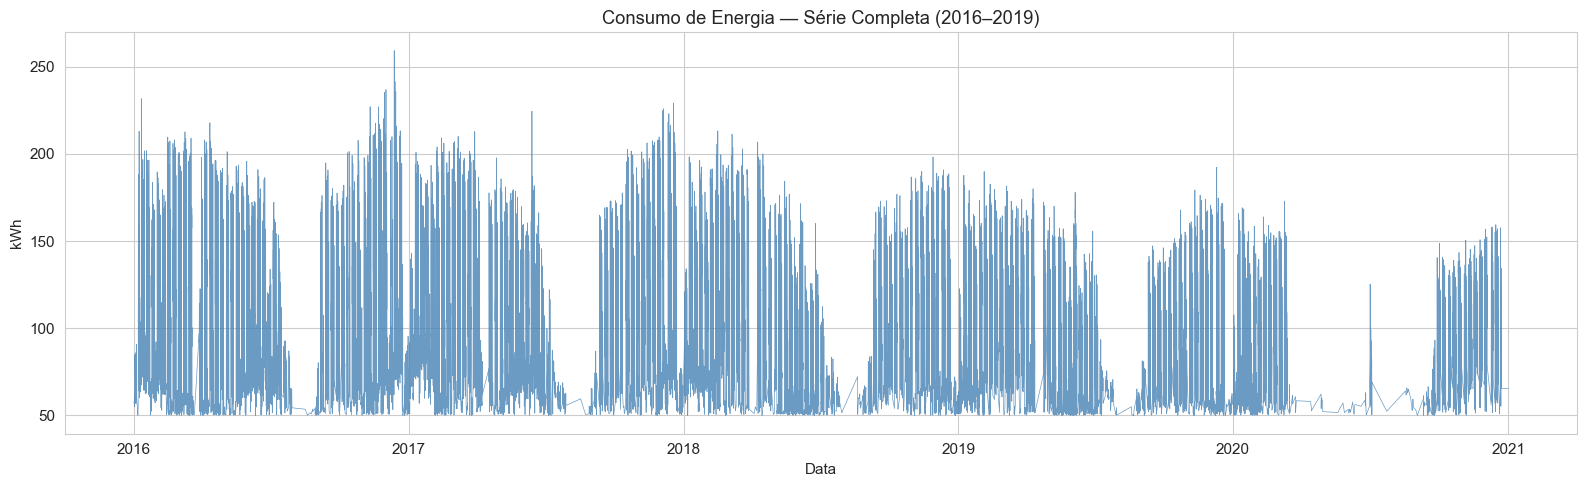

In [5]:
# Verificação rápida de integridade
print("=== VERIFICAÇÃO DOS DADOS ===")
print(f"Valores ausentes     : {df.isnull().sum().sum()}")
print(f"ENERGY — mín: {df['ENERGY'].min():.1f}  máx: {df['ENERGY'].max():.1f}  média: {df['ENERGY'].mean():.1f} kWh")
print()

# Gráfico do consumo ao longo do tempo
fig, ax = plt.subplots()
ax.plot(df.index, df['ENERGY'], linewidth=0.5, color='steelblue', alpha=0.8)
ax.set_title('Consumo de Energia — Série Completa (2016–2019)')
ax.set_xlabel('Data')
ax.set_ylabel('kWh')
plt.tight_layout()
plt.show()


---
## Seção 3 — Divisão Treino / Teste

### Por que não podemos embaralhar os dados?

Em problemas normais de Machine Learning (classificar e-mails como spam, por exemplo),  
os exemplos são independentes entre si e podemos embaralhá-los livremente.

Em **séries temporais**, cada ponto no tempo depende dos anteriores.  
Se embaralharmos, o modelo "vê o futuro" durante o treinamento — isso é chamado de **data leakage**  
e produz resultados irrealisticamente bons que não se repetem na prática.

### A divisão que seguimos:

| Período | Uso |
|---|---|
| 2016, 2017, 2018 | **Treino** — o modelo aprende aqui |
| 2019 | **Teste** — avaliamos o modelo aqui, como se fosse o futuro |



Treino : 2016-01-01 → 2018-12-31  (26,304 horas)
Teste  : 2019-01-01 → 2019-12-31   (8,760 horas)


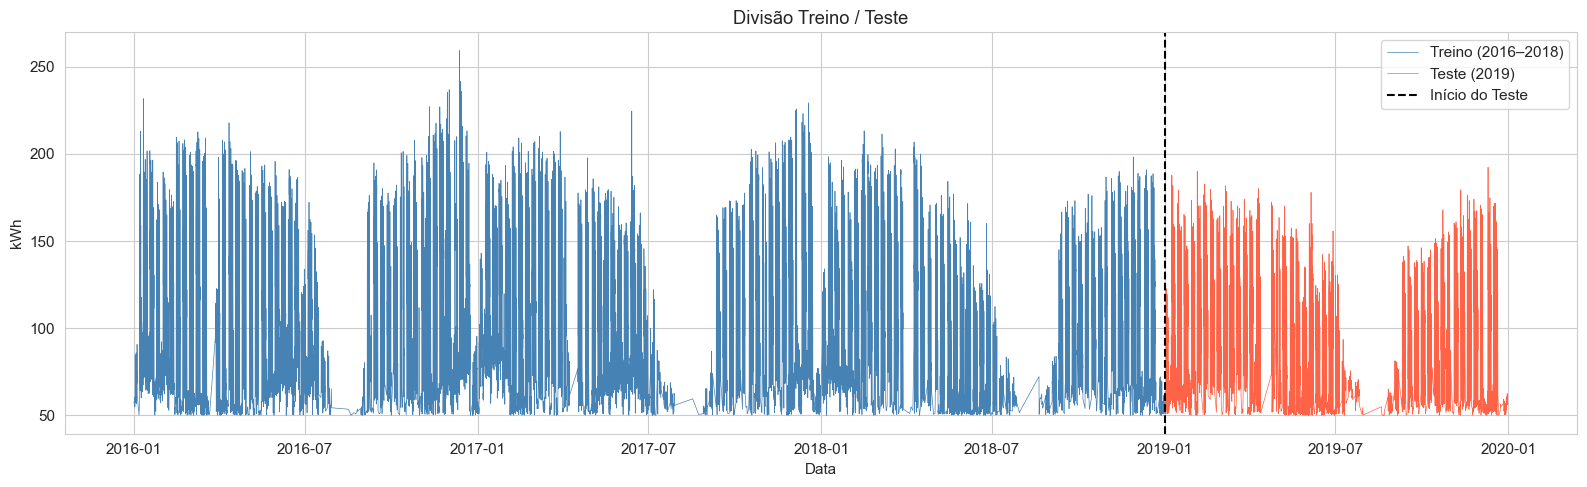

In [6]:
# Divisão temporal: treino = 2016–2018, teste = 2019
# O modelo aprende com o passado e é avaliado no "futuro" (2019)

train_df = df[df.index.year <= 2018].copy()
test_df  = df[df.index.year == 2019].copy()

print(f"Treino : {train_df.index.min().date()} → {train_df.index.max().date()}  ({len(train_df):,} horas)")
print(f"Teste  : {test_df.index.min().date()} → {test_df.index.max().date()}   ({len(test_df):,} horas)")

# Visualização da divisão
fig, ax = plt.subplots()
ax.plot(train_df.index, train_df['ENERGY'], color='steelblue', linewidth=0.5, label='Treino (2016–2018)')
ax.plot(test_df.index,  test_df['ENERGY'],  color='tomato',    linewidth=0.5, label='Teste (2019)')
ax.axvline(x=test_df.index.min(), color='black', linestyle='--', linewidth=1.5, label='Início do Teste')
ax.set_title('Divisão Treino / Teste')
ax.set_xlabel('Data')
ax.set_ylabel('kWh')
ax.legend()
plt.tight_layout()
plt.show()


---
## Seleção das Features de Entrada

Definimos quais colunas entram como entrada (X) do modelo e qual é a saída (y).

### Features utilizadas

Seguimos o mesmo conjunto do paper de referência (Mariano-Hernández et al., 2021):

| Tipo | Variáveis |
|---|---|
| **Climáticas** | T2M, T2M_MAX, ALLSKY (as de maior importância segundo o Random Forest do paper) |
| **Calendário (seno/cosseno)** | hour_sin, hour_cos, day_of_week_sin, day_of_week_cos, month_sin, month_cos |
| **Calendário (direto)** | is_weekend, HOLIDAY |
| **TARGET (saída)** | ENERGY |

### Por que seno e cosseno para hora e dia?

A hora 23 e a hora 0 são vizinhas no tempo, mas numericamente distantes (23 vs 0).  
Se passarmos o número direto, o modelo trata como se fossem "muito diferentes".  
A codificação em seno/cosseno resolve isso: transforma o ciclo numa circunferência,  
onde 23h e 0h ficam próximos no espaço matemático.


In [7]:
# Definição das colunas de entrada (features) e saída (target)

FEATURE_COLS = [
    # Variáveis climáticas (maior importância segundo o paper)
    'T2M', 'T2M_MAX', 'ALLSKY',
    # Calendário em seno/cosseno (codificação cíclica)
    'hour_sin', 'hour_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'month_sin', 'month_cos',
    # Calendário direto
    'is_weekend', 'HOLIDAY',
    # TARGET: o consumo de energia é tanto uma feature de entrada (histórico)
    # quanto o que queremos prever. A posição [0] desta lista é usada como saída.
    'ENERGY',
]

# Reorganizamos para ENERGY ficar na posição 0 (facilita extrair a saída depois)
FEATURE_COLS = ['ENERGY'] + [c for c in FEATURE_COLS if c != 'ENERGY']
TARGET_IDX = 0  # índice da coluna ENERGY dentro de FEATURE_COLS

print(f"Features selecionadas ({len(FEATURE_COLS)} colunas):")
for i, col in enumerate(FEATURE_COLS):
    marcador = ' ← TARGET' if i == TARGET_IDX else ''
    print(f"  [{i}] {col}{marcador}")

# Verifica se todas as colunas existem no dataframe
faltando = [c for c in FEATURE_COLS if c not in df.columns]
if faltando:
    print(f"\n  Colunas não encontradas: {faltando}")
    print("    Verifique se o notebook de pré-processamento foi executado corretamente.")
else:
    print("\n Todas as colunas encontradas no dataset.")


Features selecionadas (12 colunas):
  [0] ENERGY ← TARGET
  [1] T2M
  [2] T2M_MAX
  [3] ALLSKY
  [4] hour_sin
  [5] hour_cos
  [6] day_of_week_sin
  [7] day_of_week_cos
  [8] month_sin
  [9] month_cos
  [10] is_weekend
  [11] HOLIDAY

 Todas as colunas encontradas no dataset.


---
## Normalização dos Dados

### Por que normalizar?

Redes neurais são extremamente sensíveis à escala dos dados.  
Imagine que o consumo varia entre 50 e 450 kWh, enquanto a temperatura varia entre -5 e 40°C.

Se passarmos esses valores brutos, o gradiente da rede vai ser dominado pela variável  
com os maiores números (consumo), dificultando o aprendizado das demais.

A normalização coloca **todas as variáveis na mesma escala**, geralmente entre 0 e 1.

### A regra de ouro: fit só no treino

O `scaler.fit()` aprende os valores mínimo e máximo de cada coluna.  
**Ele deve aprender apenas com os dados de treino**, e então aplicar essa mesma  
escala ao teste.

Se fizéssemos `fit` em todos os dados juntos, estaríamos usando informação do período  
de teste para construir o modelo, isso é **data leakage**.


In [8]:
# Extrai apenas as colunas selecionadas
train_arr = train_df[FEATURE_COLS].values  # numpy array do treino
test_arr  = test_df[FEATURE_COLS].values   # numpy array do teste

# MinMaxScaler: transforma cada coluna para o intervalo [0, 1]
# usando: x_normalizado = (x - x_min) / (x_max - x_min)
scaler = MinMaxScaler(feature_range=(0, 1))

# fit_transform: aprende os min/max do TREINO e já normaliza o treino
train_scaled = scaler.fit_transform(train_arr)

# transform: aplica os mesmos min/max aprendidos no treino para o teste
# (sem re-aprender — isso é intencional!)
test_scaled = scaler.transform(test_arr)

print("Normalização aplicada.")
print(f"  Treino : shape {train_scaled.shape} linhas/horas de treino - colunas  |  mín={train_scaled.min():.3f}   máx={train_scaled.max():.3f}")
print(f"  Teste  : shape {test_scaled.shape}                                    |  mín={test_scaled.min():.3f}  máx={test_scaled.max():.3f}")
print()
print("Exemplo — coluna ENERGY antes e depois da normalização:")
print(f"  Antes  → mín: {train_df['ENERGY'].min():.1f} kWh  |  máx: {train_df['ENERGY'].max():.1f} kWh")
print(f"  Depois → mín: {train_scaled[:, 0].min():.3f}     |  máx: {train_scaled[:, 0].max():.3f}")


Normalização aplicada.
  Treino : shape (26304, 12) linhas/horas de treino - colunas  |  mín=0.000   máx=1.000
  Teste  : shape (8760, 12)                                    |  mín=-0.000  máx=1.022

Exemplo — coluna ENERGY antes e depois da normalização:
  Antes  → mín: 50.0 kWh  |  máx: 259.1 kWh
  Depois → mín: 0.000     |  máx: 1.000


---
## Criação das Janelas Deslizantes (Windowing)


O LSTM não recebe uma linha do CSV por vez. Ele recebe uma **sequência de horas consecutivas**  
e aprende a prever o que vem depois.

Para prever o consumo de amanhã, nós olhamos para o que aconteceu  
nas últimas N horas, isso é a **janela de entrada**.

### Como funciona a janela deslizante

```
Horas:   [t-24] [t-23] ... [t-1] [t]  →  prever:  [t+1] [t+2] ... [t+24]
                ↑                  ↑                  ↑              ↑
           início da            fim da            primeira       última
            janela              janela            previsão       previsão
```

A janela "desliza" uma hora de cada vez ao longo de todo o dataset,  
gerando milhares de exemplos de treinamento a partir de uma única série.

### Parâmetros

- `N_LAGS = 25`: usamos as últimas 25 horas como entrada  
  (valor baseado no ACF e PACF do paper pois após 25 lags, a autocorrelação parcial cai)
- `N_AHEAD = 24`: prevemos as próximas 24 horas (estratégia day-ahead)

### Estratégia Direct Multi-Step

Ao invés de prever 1 hora e usar esse valor para prever a próxima  
(o que acumula erros), o modelo prevê **as 24 horas de uma vez**, saída com 24 neurônios.  
Isso é chamado de **Direct Multi-Step Forecasting** e é o que o paper de referência também usa.


In [9]:
# Parâmetros da janela deslizante
N_LAGS  = 25   # quantas horas de histórico o modelo "vê" para fazer a previsão
N_AHEAD = 24   # quantas horas o modelo prevê de uma vez (1 dia completo)

def create_sequences(data, n_lags, n_ahead, target_idx=0):
    """
    Transforma um array 2D (timesteps x features) em sequências para o LSTM.

    Para cada posição i:
      - X[i]: janela de n_lags timesteps anteriores  → shape (n_lags, n_features)
      - y[i]: próximos n_ahead valores do TARGET     → shape (n_ahead,)

    Parâmetros:
      data       : array normalizado (timesteps x features)
      n_lags     : tamanho da janela de entrada
      n_ahead    : horizonte de previsão
      target_idx : qual coluna é o TARGET (ENERGY está na posição 0)
    """
    X, y = [], []

    # Percorremos cada posição possível no array
    # Começamos em n_lags (para ter histórico suficiente)
    # Terminamos em len(data) - n_ahead (para ter futuro suficiente)
    for i in range(n_lags, len(data) - n_ahead + 1):
        # Janela de entrada: n_lags timesteps, todas as features
        X.append(data[i - n_lags : i, :])

        # Saída: próximos n_ahead valores, apenas a coluna TARGET (ENERGY)
        y.append(data[i : i + n_ahead, target_idx])

    return np.array(X), np.array(y)

# Criação das sequências
X_train, y_train = create_sequences(train_scaled, N_LAGS, N_AHEAD, TARGET_IDX)
X_test,  y_test  = create_sequences(test_scaled,  N_LAGS, N_AHEAD, TARGET_IDX)

print("Sequências criadas!")
print()
print(f"X_train shape: {X_train.shape}")
# O índice [0] é a dimensão 1: Número total de amostras (janelas de entrada) geradas.
print(f"  → {X_train.shape[0]:,} exemplos de treinamento")
# O índice [1] é a dimensão 2: O tamanho do histórico inserido (N_LAGS = 25 horas).
print(f"  → cada exemplo tem {X_train.shape[1]} timesteps (horas de histórico)")
# O índice [2] é a dimensão 3: A quantidade total de colunas usadas (temperatura, hora, consumo, etc.).
print(f"  → cada timestep tem {X_train.shape[2]} features")
print()
# y_train.shape é uma tupla com 2 valores: (amostras, horizonte de previsão)
print(f"y_train shape: {y_train.shape}")
print(f"  → {y_train.shape[0]:,} exemplos, cada um com {y_train.shape[1]} horas a prever")
print()
print(f"X_test  shape: {X_test.shape}")
print(f"y_test  shape: {y_test.shape}")


Sequências criadas!

X_train shape: (26256, 25, 12)
  → 26,256 exemplos de treinamento
  → cada exemplo tem 25 timesteps (horas de histórico)
  → cada timestep tem 12 features

y_train shape: (26256, 24)
  → 26,256 exemplos, cada um com 24 horas a prever

X_test  shape: (8712, 25, 12)
y_test  shape: (8712, 24)


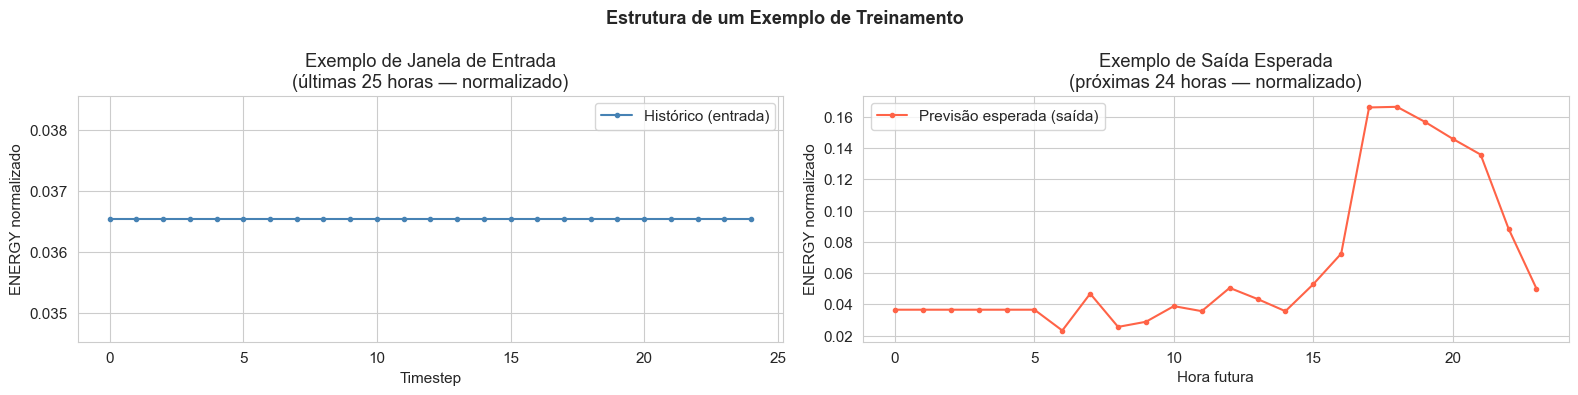

Cada exemplo de treino: o modelo vê 25h de histórico e aprende a prever as 24h seguintes.


In [10]:
# Visualização do conceito de janela deslizante
# Mostra as primeiras janelas para entender o que está acontecendo

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Painel esquerdo: janela de entrada (X)
axes[0].plot(range(N_LAGS), X_train[0, :, TARGET_IDX], marker='o', markersize=3,
             color='steelblue', label='Histórico (entrada)')
axes[0].set_title(f'Exemplo de Janela de Entrada\n(últimas {N_LAGS} horas — normalizado)')
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('ENERGY normalizado')
axes[0].legend()

# Painel direito: saída esperada (y)
axes[1].plot(range(N_AHEAD), y_train[0, :], marker='o', markersize=3,
             color='tomato', label='Previsão esperada (saída)')
axes[1].set_title(f'Exemplo de Saída Esperada\n(próximas {N_AHEAD} horas — normalizado)')
axes[1].set_xlabel('Hora futura')
axes[1].set_ylabel('ENERGY normalizado')
axes[1].legend()

plt.suptitle('Estrutura de um Exemplo de Treinamento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Cada exemplo de treino: o modelo vê 25h de histórico e aprende a prever as 24h seguintes.")


---
##Seção 7 — Arquitetura do Modelo LSTM

### O que é uma rede LSTM?

LSTM significa **Long Short-Term Memory** (Memória de Longo e Curto Prazo).  
É um tipo especial de rede neural recorrente, projetada para aprender padrões em sequências temporais.

O problema que ela resolve: redes recorrentes simples "esquecem" o passado distante  
(o chamado problema do vanishing gradient). O LSTM resolve isso com um sistema de **portas (gates)**:

- **Forget gate**: decide o que esquecer da memória anterior
- **Input gate**: decide o que guardar da entrada atual
- **Output gate**: decide o que usar da memória para gerar a saída

Pense como nossa memória: você não guarda todos os detalhes de um dia, mas guarda  
o que é relevante para entender o dia seguinte.

### Nossa arquitetura

```
Entrada: (25 timesteps × 12 features)
    ↓
LSTM — 128 unidades (processa a sequência temporal)
    ↓
Dropout 20% (regularização: previne overfitting do modelo)
    ↓
LSTM — 64 unidades (refina a representação aprendida)
    ↓
Dropout 20%
    ↓
Dense — 24 unidades, ativação linear (saída: as 24 horas previstas)
```

### Por que duas camadas LSTM?

A primeira camada aprende padrões mais simples (hora do dia, dia da semana).  
A segunda aprende padrões mais complexos construídos sobre os anteriores (sazonalidade, efeito de holidays).

### O que é Dropout?

Durante o treino, o Dropout desativa aleatoriamente uma fração dos neurônios a cada batch.  
Isso força a rede a não depender de nenhum neurônio específico, tornando-a mais robusta  
e menos propensa a memorizar o treino (overfitting).


In [11]:
# Dimensões de entrada
n_timesteps = X_train.shape[1]  # 25 horas de histórico
n_features  = X_train.shape[2]  # número de features por timestep

print(f"Entrada do modelo: {n_timesteps} timesteps × {n_features} features")
print()

# Construção do modelo Sequential (camadas empilhadas em sequência)
model = Sequential(name='LSTM_Energy_Forecast')

# ── Camada 1: LSTM com 128 unidades ──────────────────────────────────────
# return_sequences=True: passa a sequência inteira para a próxima camada LSTM
# (se fosse False, só passaria o último estado — necessário quando LSTM é a última camada recorrente)
model.add(LSTM(
    units=128,
    return_sequences=True,
    input_shape=(n_timesteps, n_features),
    name='lstm_1'
))

# Dropout 20%: desativa 20% dos neurônios aleatoriamente durante o treino
model.add(Dropout(0.2, name='dropout_1'))

# ── Camada 2: LSTM com 64 unidades ───────────────────────────────────────
# return_sequences=False: agora só precisamos do estado final
model.add(LSTM(
    units=64,
    return_sequences=False,
    name='lstm_2'
))

model.add(Dropout(0.2, name='dropout_2'))

# ── Camada de saída: 24 neurônios (um por hora prevista) ─────────────────
# Ativação linear: sem restrição na saída (adequado para regressão)
model.add(Dense(units=N_AHEAD, activation='linear', name='output'))

# Compilação: define como o modelo vai aprender
# - Adam: otimizador adaptativo (bom padrão para LSTM)
# - MSE: loss function — penaliza erros grandes mais do que erros pequenos
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mae']
)

# Resumo da arquitetura
model.summary()


Entrada do modelo: 25 timesteps × 12 features

Model: "LSTM_Energy_Forecast"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 25, 128)           72192     
                                                                 
 dropout_1 (Dropout)         (None, 25, 128)           0         
                                                                 
 lstm_2 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 output (Dense)              (None, 24)                1560      
                                                                 
Total params: 123,160
Trainable params: 123,160
Non-trainable params: 0
___________________________________________________________

---
##Seção 8 — Treinamento do Modelo

### Conceitos importantes

**Epoch**: uma passagem completa por todos os dados de treino.  
O modelo vai ajustando os pesos a cada epoch para minimizar o erro.

**Batch size**: quantos exemplos o modelo processa antes de atualizar os pesos.  
Batch pequeno (5) = atualizações frequentes = aprendizado mais fino, mas mais lento.

**Validation split**: uma parte do treino é reservada para monitorar o aprendizado  
sem que o modelo "estude" esses dados. Aqui usamos os últimos 10% do treino.

### Callbacks (paradas automáticas)

**EarlyStopping**: para o treino automaticamente se o erro de validação parar de melhorar.  
Isso evita desperdiçar tempo e evita overfitting (quando o modelo "decora" o treino).

**ModelCheckpoint**: salva automaticamente o modelo no momento em que ele teve  
o melhor desempenho na validação — não necessariamente no último epoch.




In [12]:
# Callbacks: comportamentos automáticos durante o treinamento

# EarlyStopping: para o treino se val_loss não melhorar por 15 epochs consecutivos
# restore_best_weights=True: ao final, restaura os pesos do melhor epoch
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# ModelCheckpoint: salva o modelo sempre que val_loss melhora
checkpoint = ModelCheckpoint(
    filepath='lstm_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

print("Iniciando treinamento...")
print(f"  Epochs máximos : 100 (pode parar antes pelo EarlyStopping)")
print(f"  Batch size     : 16")
print(f"  Validação      : 10% do treino")
print()

# Treinamento
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,   # últimos 10% do treino viram validação
    callbacks=[early_stop, checkpoint],
    shuffle=False,           # NÃO embaralha — ordem temporal importa!
    verbose=1
)

print()
print("Treinamento concluído!")
print(f"   Melhor epoch      : {np.argmin(history.history['val_loss']) + 1}")
print(f"   Melhor val_loss   : {min(history.history['val_loss']):.6f}")


Iniciando treinamento...
  Epochs máximos : 100 (pode parar antes pelo EarlyStopping)
  Batch size     : 16
  Validação      : 10% do treino

Epoch 1/100
1477/1477 [==============================] - 34s 13ms/step - loss: 0.0270 - mae: 0.1176 - val_loss: 0.0177 - val_mae: 0.0932
Epoch 2/100
1477/1477 [==============================] - 18s 12ms/step - loss: 0.0167 - mae: 0.0935 - val_loss: 0.0123 - val_mae: 0.0812
Epoch 3/100
1477/1477 [==============================] - 17s 12ms/step - loss: 0.0144 - mae: 0.0862 - val_loss: 0.0109 - val_mae: 0.0770
Epoch 4/100
1477/1477 [==============================] - 18s 12ms/step - loss: 0.0128 - mae: 0.0802 - val_loss: 0.0100 - val_mae: 0.0733
Epoch 5/100
1477/1477 [==============================] - 18s 13ms/step - loss: 0.0116 - mae: 0.0757 - val_loss: 0.0092 - val_mae: 0.0692
Epoch 6/100
1477/1477 [==============================] - 18s 12ms/step - loss: 0.0107 - mae: 0.0724 - val_loss: 0.0087 - val_mae: 0.0661
Epoch 7/100
1477/1477 [=============

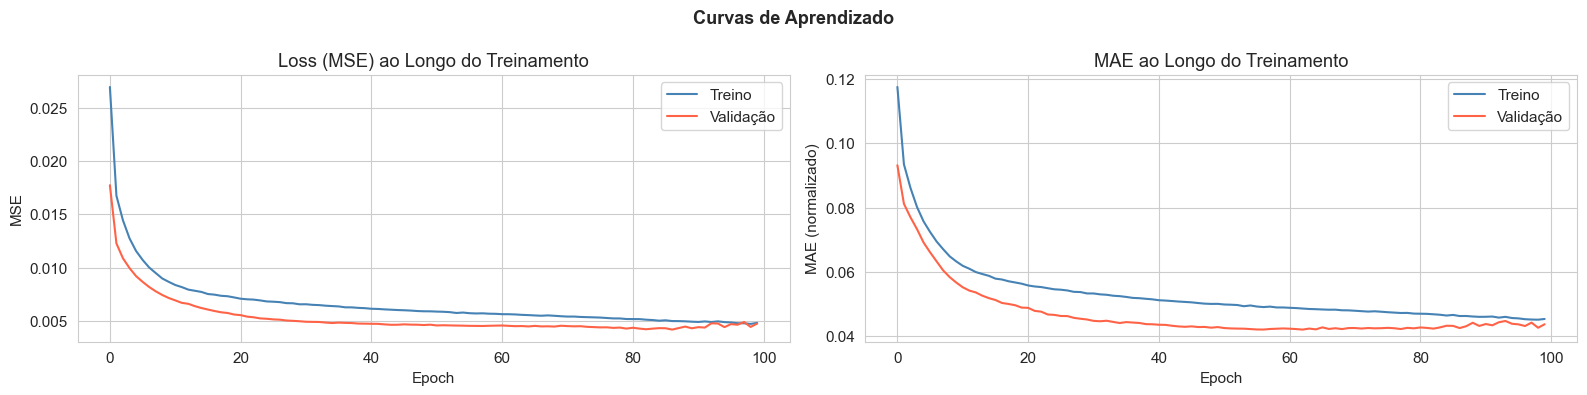


O que observar:
  • Ambas as curvas (treino e validação) devem cair juntas.
  • Se a curva de treino cair mas a de validação subir → overfitting.
  • Se ambas estagnarem cedo → underfitting (modelo simples demais).


In [13]:
# Gráfico de aprendizado: loss ao longo dos epochs
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Loss (MSE)
axes[0].plot(history.history['loss'],     label='Treino',     color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validação',  color='tomato')
axes[0].set_title('Loss (MSE) ao Longo do Treinamento')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

# MAE
axes[1].plot(history.history['mae'],     label='Treino',     color='steelblue')
axes[1].plot(history.history['val_mae'], label='Validação',  color='tomato')
axes[1].set_title('MAE ao Longo do Treinamento')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (normalizado)')
axes[1].legend()

plt.suptitle('Curvas de Aprendizado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("O que observar:")
print("  • Ambas as curvas (treino e validação) devem cair juntas.")
print("  • Se a curva de treino cair mas a de validação subir → overfitting.")
print("  • Se ambas estagnarem cedo → underfitting (modelo simples demais).")


---
## Seção 9 — Geração das Previsões

Agora usamos o modelo treinado para prever o consumo do período de teste (2019).

Um passo crucial: as previsões saem **normalizadas** (entre 0 e 1).  
Precisamos **desnormalizar** para voltar para kWh e calcular as métricas reais.

A desnormalização é feita com `scaler.inverse_transform()`.  
Como o scaler foi treinado com múltiplas colunas, precisamos  
de um truque: criar um array com zeros nas outras colunas e só ENERGY preenchida,  
aplicar o inverse_transform, e extrair a coluna ENERGY.


In [14]:
# Geração das previsões no conjunto de teste
y_pred_scaled = model.predict(X_test, verbose=0)

print(f"Previsões geradas: {y_pred_scaled.shape}")
print(f"  → {y_pred_scaled.shape[0]} janelas de previsão")
print(f"  → cada uma com {y_pred_scaled.shape[1]} horas previstas")

# ── Desnormalização ────────────────────────────────────────────────────────
# O scaler foi ajustado com n_features colunas.
# Para usar inverse_transform, precisamos fornecer um array com o mesmo número de colunas.
# Preenchemos com zeros as colunas que não são ENERGY, e extraímos apenas a coluna TARGET.

n_features_total = len(FEATURE_COLS)

def inverse_transform_target(scaled_values, scaler, target_idx, n_features):
    """
    Desnormaliza apenas a coluna TARGET de um array de previsões.

    scaled_values : array (n_samples, n_ahead) — previsões normalizadas
    scaler        : MinMaxScaler ajustado com todas as features
    target_idx    : índice da coluna TARGET
    n_features    : número total de features do scaler
    """
    # Resultado desnormalizado
    result = np.zeros_like(scaled_values)

    for i in range(scaled_values.shape[0]):
        # Cria array temporário com zeros em todas as colunas
        temp = np.zeros((scaled_values.shape[1], n_features))
        # Preenche a coluna TARGET com as previsões normalizadas
        temp[:, target_idx] = scaled_values[i, :]
        # Desnormaliza (inverse_transform atua em todas as colunas)
        temp_inv = scaler.inverse_transform(temp)
        # Extrai apenas a coluna TARGET desnormalizada
        result[i, :] = temp_inv[:, target_idx]

    return result

# Desnormaliza previsões e valores reais
y_pred_kwh = inverse_transform_target(y_pred_scaled, scaler, TARGET_IDX, n_features_total)
y_test_kwh = inverse_transform_target(y_test,        scaler, TARGET_IDX, n_features_total)

print()
print(f"Previsões em kWh — mín: {y_pred_kwh.min():.1f}  máx: {y_pred_kwh.max():.1f}  média: {y_pred_kwh.mean():.1f}")
print(f"Reais     em kWh — mín: {y_test_kwh.min():.1f}  máx: {y_test_kwh.max():.1f}  média: {y_test_kwh.mean():.1f}")

Previsões geradas: (8712, 24)
  → 8712 janelas de previsão
  → cada uma com 24 horas previstas

Previsões em kWh — mín: 37.5  máx: 231.1  média: 78.9
Reais     em kWh — mín: 50.0  máx: 192.3  média: 76.1


---
## Seção 10 — Avaliação do Modelo

### Métricas utilizadas (mesmas do paper de referência)

| Métrica | Nome completo | O que mede | Melhor valor |
|---|---|---|---|
| **R²** | Coeficiente de Determinação | Proporção da variância explicada pelo modelo | 1.0 |
| **RMSE** | Root Mean Squared Error | Erro médio em kWh (penaliza erros grandes) | 0 |
| **MAE** | Mean Absolute Error | Erro médio absoluto em kWh | 0 |
| **MAPE** | Mean Absolute Percentage Error | Erro médio em % | 0% |

O **MAPE** é a métrica principal de comparação com o paper, pois é adimensional  
e permite comparar o desempenho entre os dois prédios (que têm escalas diferentes).

In [15]:
# ── Cálculo das métricas ──────────────────────────────────────────────────
# Achatamos para comparar todos os valores de uma vez
y_true_flat = y_test_kwh.flatten()
y_pred_flat = y_pred_kwh.flatten()

# R² — coeficiente de determinação
r2 = r2_score(y_true_flat, y_pred_flat)

# RMSE — raiz do erro quadrático médio
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))

# MAE — erro absoluto médio
mae = mean_absolute_error(y_true_flat, y_pred_flat)

# MAPE — erro percentual absoluto médio
# Ignoramos divisões por zero (consumo = 0) usando máscara
mask = y_true_flat != 0
mape = np.mean(np.abs((y_true_flat[mask] - y_pred_flat[mask]) / y_true_flat[mask])) * 100

print("=" * 45)
print("      RESULTADOS DO MODELO LSTM")
print("=" * 45)
print(f"  R²    : {r2:.4f}   (paper LSTM: 0.79)")
print(f"  RMSE  : {rmse:.2f} kWh  (paper LSTM: 32.26 kWh)")
print(f"  MAE   : {mae:.2f} kWh  (paper LSTM: 17.74 kWh)")
print(f"  MAPE  : {mape:.2f}%    (paper LSTM: 10.18%)")
print("=" * 45)
print()
print("Referência — paper Mariano-Hernández et al. (2021), Prédio 1:")
print("  Melhor modelo individual: XGBoost (MAPE 8.83%)")
print("  Melhor ensemble (5 modelos): MAPE 7.85%")
print()
if mape < 15:
    print("✅ MAPE abaixo de 15% — bom resultado para previsão de energia!")
elif mape < 20:
    print("🟡 MAPE entre 15–20% — resultado razoável, há espaço para melhoria.")
else:
    print("🔴 MAPE acima de 20% — vale investigar overfitting ou hiperparâmetros.")

      RESULTADOS DO MODELO LSTM
  R²    : 0.7989   (paper LSTM: 0.79)
  RMSE  : 13.91 kWh  (paper LSTM: 32.26 kWh)
  MAE   : 8.71 kWh  (paper LSTM: 17.74 kWh)
  MAPE  : 11.44%    (paper LSTM: 10.18%)

Referência — paper Mariano-Hernández et al. (2021), Prédio 1:
  Melhor modelo individual: XGBoost (MAPE 8.83%)
  Melhor ensemble (5 modelos): MAPE 7.85%

✅ MAPE abaixo de 15% — bom resultado para previsão de energia!


---
## Seção 11 — Visualização das Previsões

Visualizamos as previsões do modelo comparadas com os valores reais.  
Isso é tão importante quanto as métricas: permite identificar  
padrões de erro (o modelo é pior em certos períodos? fins de semana? verão?).

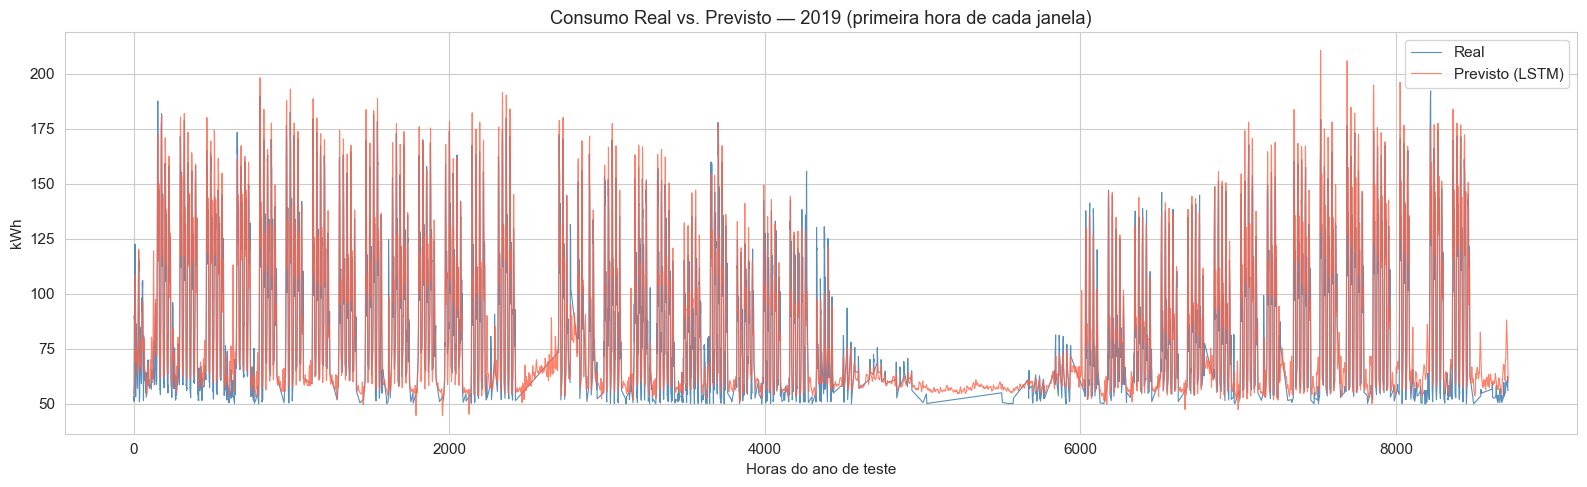

In [16]:
# ── Gráfico 1: Série completa de 2019 ────────────────────────────────────
# Cada janela prevê 24h; usamos apenas a primeira hora de cada janela
# para montar uma série contínua sem sobreposições
y_true_series = y_test_kwh[:, 0]
y_pred_series = y_pred_kwh[:, 0]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(range(len(y_true_series)), y_true_series, color='steelblue',
        linewidth=0.8, label='Real', alpha=0.9)
ax.plot(range(len(y_pred_series)), y_pred_series, color='tomato',
        linewidth=0.8, label='Previsto (LSTM)', alpha=0.8)
ax.set_title('Consumo Real vs. Previsto — 2019 (primeira hora de cada janela)')
ax.set_xlabel('Horas do ano de teste')
ax.set_ylabel('kWh')
ax.legend()
plt.tight_layout()
plt.show()

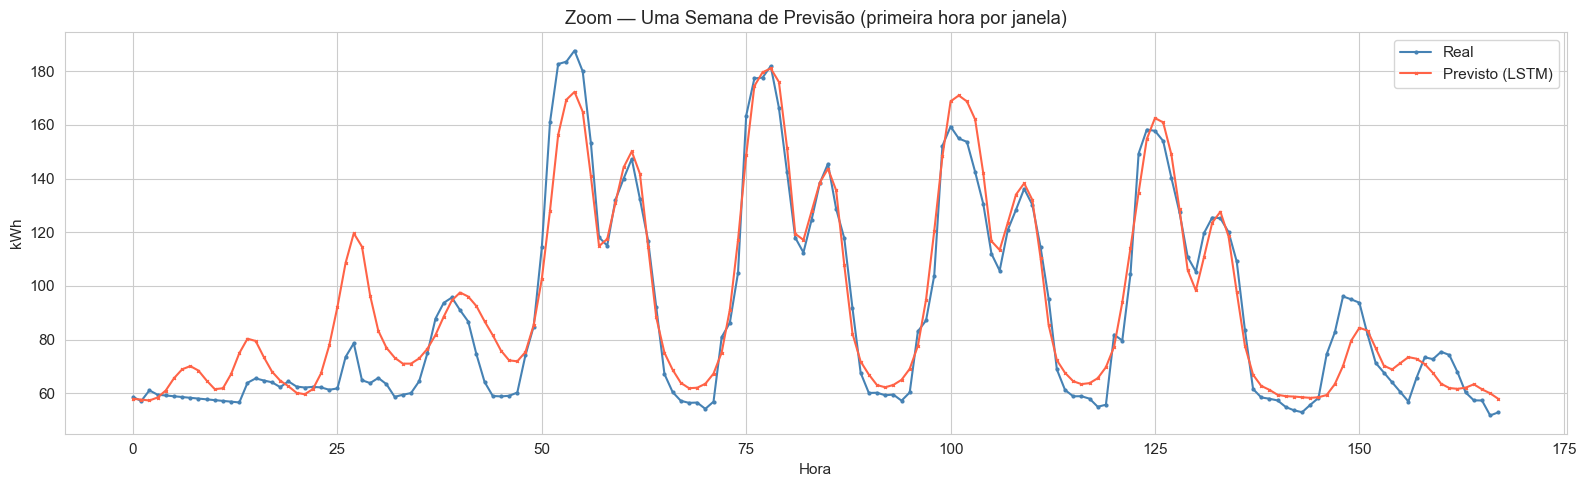

In [17]:
# ── Gráfico 2: Zoom em uma semana específica ─────────────────────────────
# Mostra os detalhes de uma semana para avaliar o comportamento diário
SEMANA_INICIO = 100   # Janela de índice 100 (aproximadamente início de maio)
SEMANA_FIM    = 268   # 168 horas = 7 dias

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_true_series[SEMANA_INICIO:SEMANA_FIM], color='steelblue',
        linewidth=1.5, label='Real', marker='o', markersize=2)
ax.plot(y_pred_series[SEMANA_INICIO:SEMANA_FIM], color='tomato',
        linewidth=1.5, label='Previsto (LSTM)', marker='x', markersize=2)
ax.set_title('Zoom — Uma Semana de Previsão (primeira hora por janela)')
ax.set_xlabel('Hora')
ax.set_ylabel('kWh')
ax.legend()
plt.tight_layout()
plt.show()

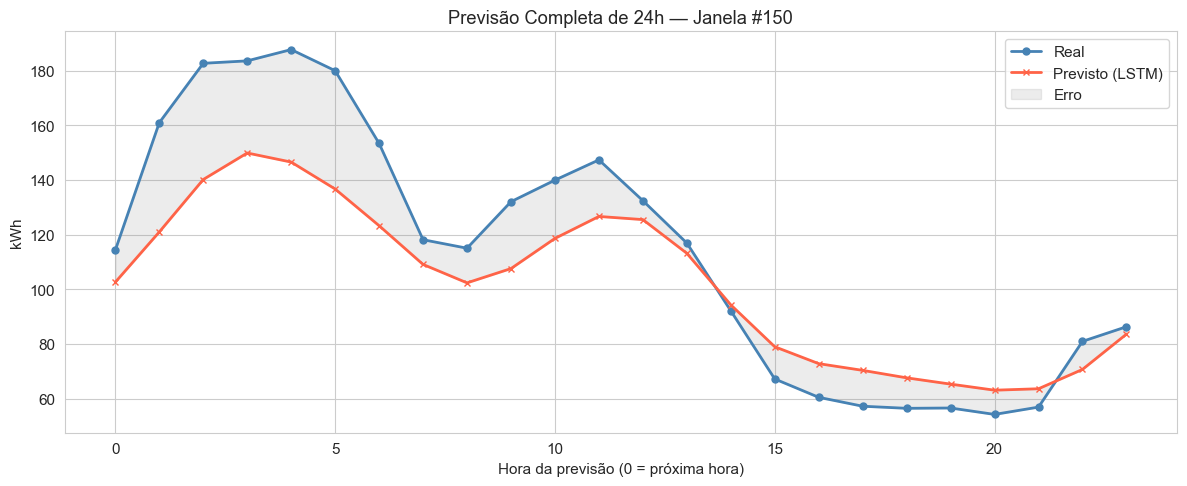

Métricas desta janela específica — MAPE: 14.99%  |  RMSE: 22.22 kWh


In [18]:
# ── Gráfico 3: Previsão completa de 24h de um dia específico ────────────
DIA_IDX = 150  # índice da janela a visualizar (mude para explorar outros dias)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(N_AHEAD), y_test_kwh[DIA_IDX, :], color='steelblue',
        linewidth=2, marker='o', markersize=5, label='Real')
ax.plot(range(N_AHEAD), y_pred_kwh[DIA_IDX, :], color='tomato',
        linewidth=2, marker='x', markersize=5, label='Previsto (LSTM)')
ax.fill_between(range(N_AHEAD),
                y_test_kwh[DIA_IDX, :],
                y_pred_kwh[DIA_IDX, :],
                alpha=0.15, color='gray', label='Erro')
ax.set_title(f'Previsão Completa de 24h — Janela #{DIA_IDX}')
ax.set_xlabel('Hora da previsão (0 = próxima hora)')
ax.set_ylabel('kWh')
ax.legend()
plt.tight_layout()
plt.show()

# Métricas deste dia específico
dia_mape = np.mean(np.abs((y_test_kwh[DIA_IDX] - y_pred_kwh[DIA_IDX]) / y_test_kwh[DIA_IDX])) * 100
dia_rmse = np.sqrt(np.mean((y_test_kwh[DIA_IDX] - y_pred_kwh[DIA_IDX])**2))
print(f"Métricas desta janela específica — MAPE: {dia_mape:.2f}%  |  RMSE: {dia_rmse:.2f} kWh")

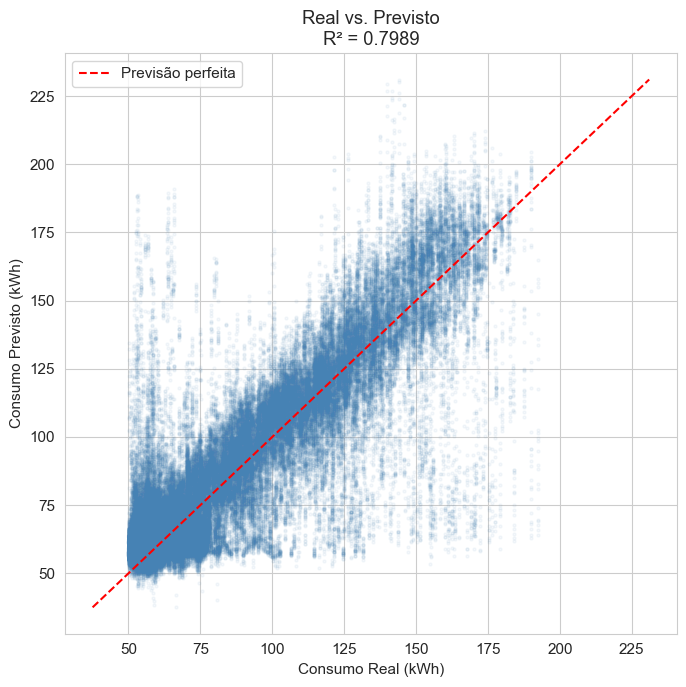

Interpretação:
  • Quanto mais próximos da linha vermelha, melhores as previsões.
  • Pontos acima da linha: modelo superestimou o consumo.
  • Pontos abaixo da linha: modelo subestimou o consumo.


In [19]:
# ── Gráfico 4: Real vs. Previsto (scatter plot) ──────────────────────────
# Pontos próximos da diagonal = boas previsões
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_true_flat, y_pred_flat, alpha=0.05, s=5, color='steelblue')

# Linha de referência: previsão perfeita (y = x)
lim_min = min(y_true_flat.min(), y_pred_flat.min())
lim_max = max(y_true_flat.max(), y_pred_flat.max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5, label='Previsão perfeita')

ax.set_title(f'Real vs. Previsto\nR² = {r2:.4f}')
ax.set_xlabel('Consumo Real (kWh)')
ax.set_ylabel('Consumo Previsto (kWh)')
ax.legend()
plt.tight_layout()
plt.show()

print("Interpretação:")
print("  • Quanto mais próximos da linha vermelha, melhores as previsões.")
print("  • Pontos acima da linha: modelo superestimou o consumo.")
print("  • Pontos abaixo da linha: modelo subestimou o consumo.")

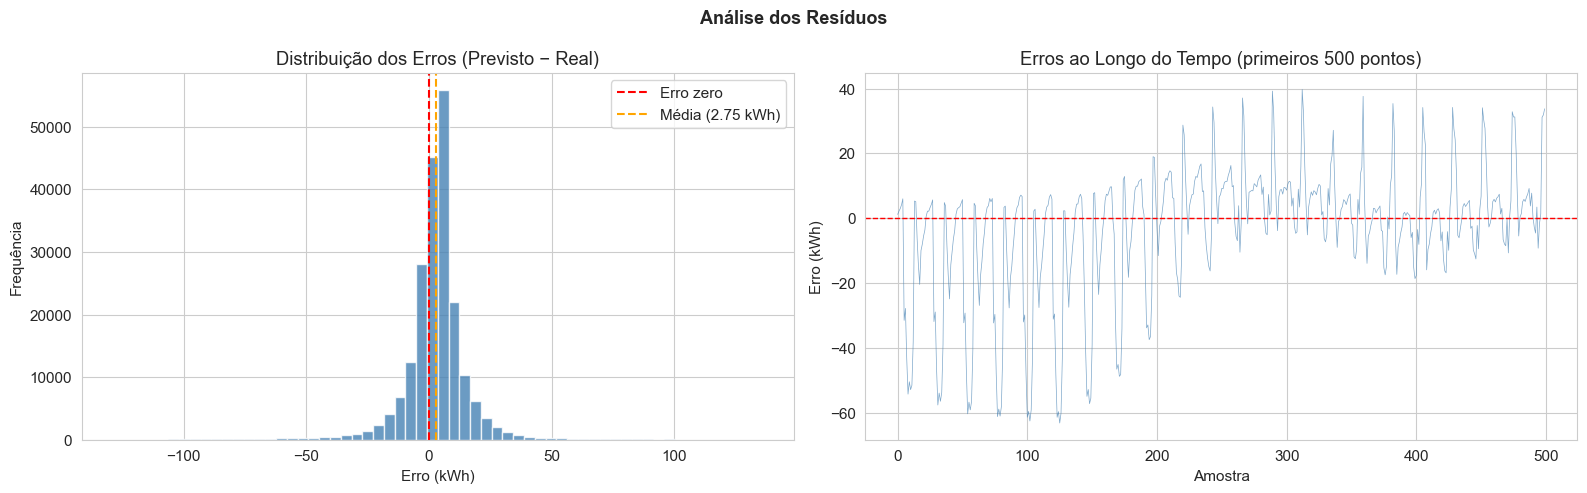

O que observar:
  • Erro médio (bias) : 2.75 kWh  (idealmente perto de 0)
  • Desvio padrão     : 13.63 kWh

Se a distribuição for centrada em 0 e simétrica → o modelo não tem viés sistemático.
Se estiver deslocada → o modelo consistentemente super ou subestima.


In [20]:
# ── Gráfico 5: Distribuição dos erros ────────────────────────────────────
erros = y_pred_flat - y_true_flat

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma dos erros
axes[0].hist(erros, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Erro zero')
axes[0].axvline(erros.mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Média ({erros.mean():.2f} kWh)')
axes[0].set_title('Distribuição dos Erros (Previsto − Real)')
axes[0].set_xlabel('Erro (kWh)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Erros ao longo do tempo
axes[1].plot(erros[:500], color='steelblue', linewidth=0.5, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Erros ao Longo do Tempo (primeiros 500 pontos)')
axes[1].set_xlabel('Amostra')
axes[1].set_ylabel('Erro (kWh)')

plt.suptitle('Análise dos Resíduos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("O que observar:")
print(f"  • Erro médio (bias) : {erros.mean():.2f} kWh  (idealmente perto de 0)")
print(f"  • Desvio padrão     : {erros.std():.2f} kWh")
print()
print("Se a distribuição for centrada em 0 e simétrica → o modelo não tem viés sistemático.")
print("Se estiver deslocada → o modelo consistentemente super ou subestima.")

---
## Seção 12 — Resumo e Próximos Passos

### O que fizemos neste notebook

1. ✅ Carregamos os dados limpos com features de calendário
2. ✅ Dividimos treino (2016–2018) e teste (2019) sem embaralhar
3. ✅ Normalizamos com MinMaxScaler, com fit apenas no treino
4. ✅ Criamos janelas deslizantes (25h de entrada → 24h de saída)
5. ✅ Construímos e treinamos uma rede LSTM com duas camadas
6. ✅ Avaliamos com R², RMSE, MAE e MAPE
7. ✅ Visualizamos as previsões e a distribuição dos erros

### Próximos passos sugeridos

- **Prédio B**: rodar o mesmo pipeline no segundo arquivo para comparar
- **Ajuste de hiperparâmetros**: testar mais unidades (256, 512) ou mais camadas
- **Modelos de referência**: implementar MLR e XGBoost para comparação (como o paper)
- **Detecção de anomalias**: usar os resíduos para sinalizar consumo anormal
  (ponto alto do TCC: erro > 2× o desvio padrão = possível anomalia)
- **Ensemble**: combinar LSTM com outros modelos (como o meanBest do paper)

